In [1]:
import pandas as pd
import os

print(os.listdir())

['.ipynb_checkpoints', 'clustering_dataset.csv.csv', 'Dimensionality_Clustering.ipynb', 'Untitled.ipynb']


In [2]:
import pandas as pd

df = pd.read_csv("clustering_dataset.csv.csv")

df.head()

,Age,Experience,Salary,Performance_Score,Projects_Completed,Training_Hours,Satisfaction_Score,Productivity_Score
0,50,10,71843,91,13,16,10,86
1,36,13,115735,80,7,77,10,86
2,29,19,41371,52,15,67,3,59
3,42,7,102371,89,5,84,7,59
4,40,17,27049,95,6,38,3,68


In [3]:
df.shape

(100, 8)

In [4]:
df.columns

Index(['Age', 'Experience', 'Salary', 'Performance_Score',
       'Projects_Completed', 'Training_Hours', 'Satisfaction_Score',
       'Productivity_Score'],
      dtype='str')

In [5]:
X = df.select_dtypes(include="number")

X.head()

,Age,Experience,Salary,Performance_Score,Projects_Completed,Training_Hours,Satisfaction_Score,Productivity_Score
0,50,10,71843,91,13,16,10,86
1,36,13,115735,80,7,77,10,86
2,29,19,41371,52,15,67,3,59
3,42,7,102371,89,5,84,7,59
4,40,17,27049,95,6,38,3,68


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[ 1.33617553, -0.01285423,  0.12271729,  0.98047787,  1.14703571,
        -1.42201075,  1.57943777,  0.7912861 ],
       [-0.14964317,  0.46917938,  1.74466903,  0.2376916 , -0.19191648,
         0.93128973,  1.57943777,  0.7912861 ],
       [-0.89255252,  1.43324661, -1.00332194, -1.65303707,  1.59335311,
         0.54550277, -0.80333473, -0.96857591],
       [ 0.48713627, -0.49488784,  1.25082589,  0.84542582, -0.63823388,
         1.20134061,  0.55824956, -0.96857591],
       [ 0.27487646,  1.11189087, -1.53256629,  1.25058196, -0.41507518,
        -0.57327943, -0.80333473, -0.38195524]])

In [8]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

X_pca[:5]

array([[ 0.50678194,  2.56477153, -0.10027051, -1.24105036, -0.28782163,
        -0.63388612,  0.12316312, -0.57924637],
       [ 0.63455643,  0.03380961,  1.52562659, -0.93703795, -1.12023012,
        -1.07408192,  0.33205226,  1.11336058],
       [ 0.66802433, -0.78253524, -0.09181997,  0.88809264, -0.7359933 ,
         2.81308604,  0.63258223, -0.54663408],
       [ 0.57115752, -0.60097761,  1.0193022 ,  0.30778081,  0.40431824,
        -1.7495096 ,  0.89902435,  0.09092137],
       [-0.28259358,  1.19490408,  0.0503052 ,  1.66387608,  1.03019207,
         0.61418119, -0.87683905, -0.17526026]])

In [9]:
pca.explained_variance_ratio_

array([0.19294853, 0.16599436, 0.14906167, 0.12899151, 0.10723799,
       0.09794558, 0.08401326, 0.0738071 ])

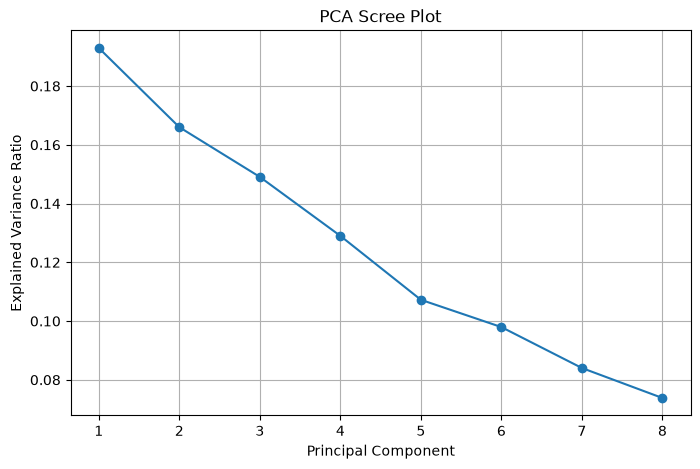

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_,
    marker="o"
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Scree Plot")
plt.xticks(range(1, len(pca.explained_variance_ratio_) + 1))
plt.grid(True)
plt.show()

In [11]:
import numpy as np

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
cumulative_variance

array([0.19294853, 0.3589429 , 0.50800456, 0.63699607, 0.74423406,
       0.84217964, 0.9261929 , 1.        ])

In [12]:
n_components = np.argmax(cumulative_variance >= 0.80) + 1
n_components

np.int64(6)

In [13]:
pca_final = PCA(n_components=n_components)
X_pca_reduced = pca_final.fit_transform(X_scaled)

X_pca_reduced.shape

(100, 6)

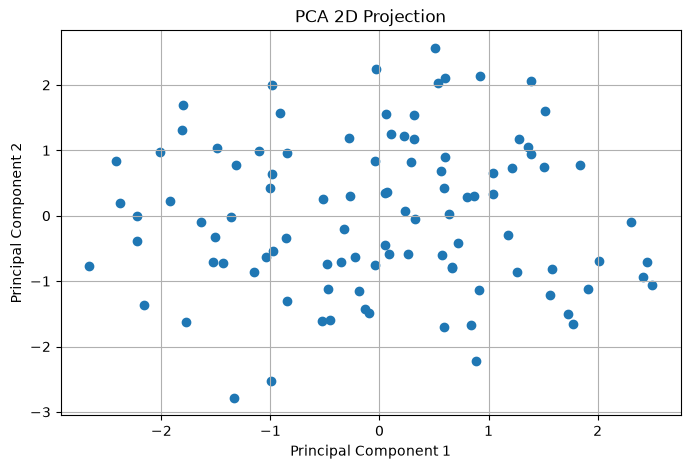

In [14]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X_pca_reduced[:, 0],
    X_pca_reduced[:, 1]
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA 2D Projection")
plt.grid(True)
plt.show()

In [15]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_pca_reduced)

clusters[:10]

array([2, 1, 2, 1, 2, 2, 1, 0, 1, 2], dtype=int32)

In [16]:
inertia = []

for k in range(2, 11):
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_pca_reduced)
    inertia.append(kmeans_temp.inertia_)

inertia


[561.626502999532,
 491.86621784994065,
 444.7820601578271,
 405.11367981317835,
 372.3087414121225,
 342.44963851799133,
 316.32419877829454,
 297.0569544434511,
 278.91518086775875]

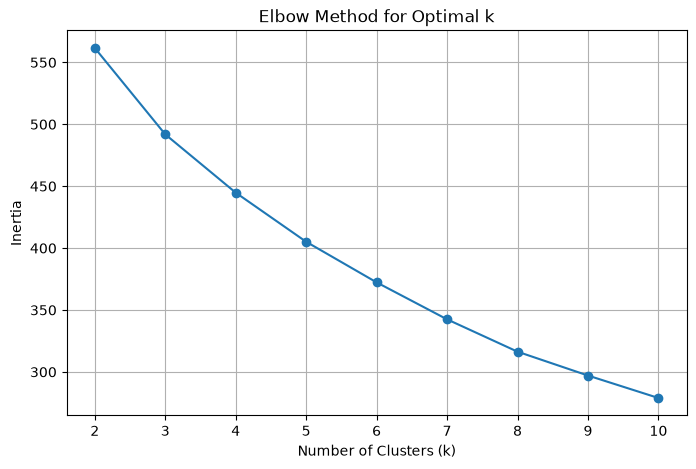

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), inertia, marker="o")

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

In [18]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans_temp.fit_predict(X_pca_reduced)
    score = silhouette_score(X_pca_reduced, labels)
    silhouette_scores.append(score)

silhouette_scores

[0.15386687643249541,
 0.14669446194487315,
 0.14426438198372427,
 0.15157027835990336,
 0.16010396905893226,
 0.1618063523710999,
 0.17679824861006238,
 0.1752491576076186,
 0.18469499836806752]

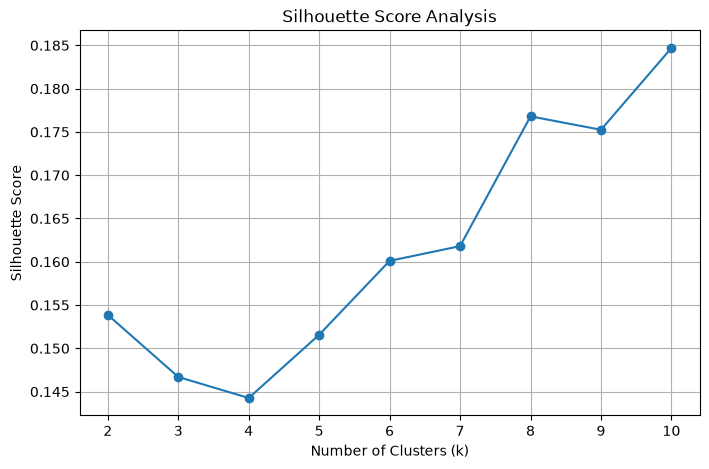

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), silhouette_scores, marker="o")

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score Analysis")
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

In [20]:
best_k = range(2, 11)[np.argmax(silhouette_scores)]
best_k

10

In [21]:
final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)

final_clusters = final_kmeans.fit_predict(X_pca_reduced)

df["Cluster"] = final_clusters

df.head()

,Age,Experience,Salary,Performance_Score,Projects_Completed,Training_Hours,Satisfaction_Score,Productivity_Score,Cluster
0,50,10,71843,91,13,16,10,86,7
1,36,13,115735,80,7,77,10,86,0
2,29,19,41371,52,15,67,3,59,2
3,42,7,102371,89,5,84,7,59,1
4,40,17,27049,95,6,38,3,68,2


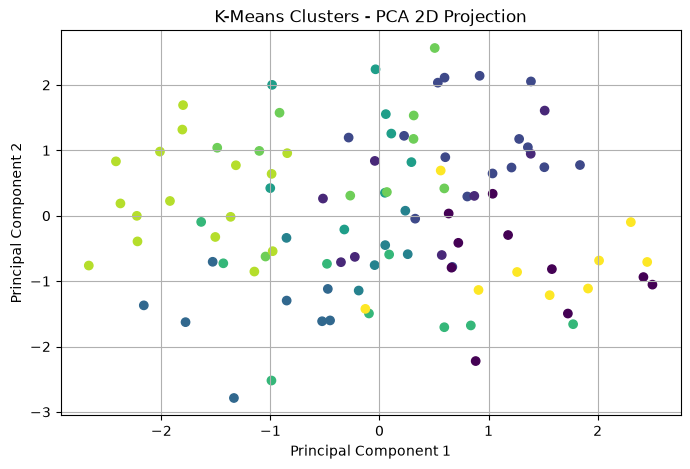

In [22]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X_pca_reduced[:, 0],
    X_pca_reduced[:, 1],
    c=final_clusters
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters - PCA 2D Projection")
plt.grid(True)
plt.show()

In [23]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_pca_reduced)

dbscan_labels[:10]

array([-1, -1, -1, -1, -1,  0, -1, -1, -1, -1])

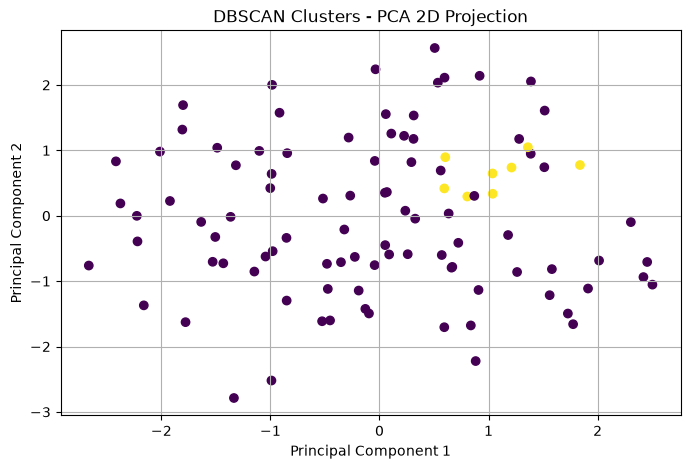

In [24]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X_pca_reduced[:, 0],
    X_pca_reduced[:, 1],
    c=dbscan_labels
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("DBSCAN Clusters - PCA 2D Projection")
plt.grid(True)
plt.show()

In [25]:
from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(n_clusters=best_k)

hierarchical_labels = hierarchical.fit_predict(X_pca_reduced)

hierarchical_labels[:10]

array([4, 3, 2, 3, 0, 0, 3, 7, 0, 4])

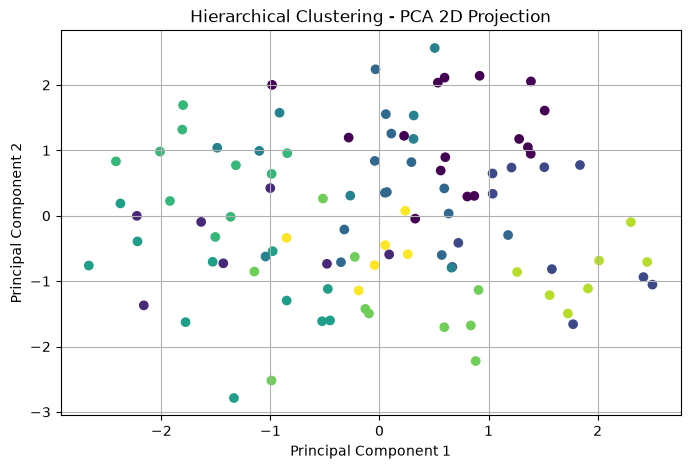

In [26]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X_pca_reduced[:, 0],
    X_pca_reduced[:, 1],
    c=hierarchical_labels
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Hierarchical Clustering - PCA 2D Projection")
plt.grid(True)
plt.show()

In [27]:
print("K-Means clusters:", len(set(final_clusters)))
print("DBSCAN clusters:", len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0))
print("Hierarchical clusters:", len(set(hierarchical_labels)))

K-Means clusters: 10
DBSCAN clusters: 1
Hierarchical clusters: 10


In [28]:
df["KMeans_Cluster"] = final_clusters
df["DBSCAN_Cluster"] = dbscan_labels
df["Hierarchical_Cluster"] = hierarchical_labels

df.head()

,Age,Experience,Salary,Performance_Score,Projects_Completed,Training_Hours,Satisfaction_Score,Productivity_Score,Cluster,KMeans_Cluster,DBSCAN_Cluster,Hierarchical_Cluster
0,50,10,71843,91,13,16,10,86,7,7,-1,4
1,36,13,115735,80,7,77,10,86,0,0,-1,3
2,29,19,41371,52,15,67,3,59,2,2,-1,2
3,42,7,102371,89,5,84,7,59,1,1,-1,3
4,40,17,27049,95,6,38,3,68,2,2,-1,0


In [29]:
df.to_csv("clustering_results.csv", index=False)

print("Clustering results saved successfully!")

Clustering results saved successfully!
